In [1]:
from utils.plots import plot_tm_roc_curve_multi_specialist
import config
import pickle
import os
from utils.dataset import load_dataset

In [2]:
_, _, _, _, _, Y_test = load_dataset(config)


Y_test unique values: [0 1 2 3 4 5 6 7]
Y_test_binarized shape: (3421, 8)
Y_test_binarized sample (first 3 rows):
[[0 0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]]

=== Canny ===
Passing to roc_auc_score — y_true shape: (3421, 8), y_score shape: (3421, 8)
Macro AUC: 0.9596
Passing to roc_curve — y_true shape: (3421,), y_score shape: (3421,)
  basophil: AUC = 0.944
Passing to roc_curve — y_true shape: (3421,), y_score shape: (3421,)
  eosinophil: AUC = 0.986
Passing to roc_curve — y_true shape: (3421,), y_score shape: (3421,)
  erythroblast: AUC = 0.914
Passing to roc_curve — y_true shape: (3421,), y_score shape: (3421,)
  immature granulocyte: AUC = 0.918
Passing to roc_curve — y_true shape: (3421,), y_score shape: (3421,)
  lymphocyte: AUC = 0.976
Passing to roc_curve — y_true shape: (3421,), y_score shape: (3421,)
  monocyte: AUC = 0.954
Passing to roc_curve — y_true shape: (3421,), y_score shape: (3421,)
  neutrophil: AUC = 0.990
Passing to roc_curve — y_true shape: (3421,)

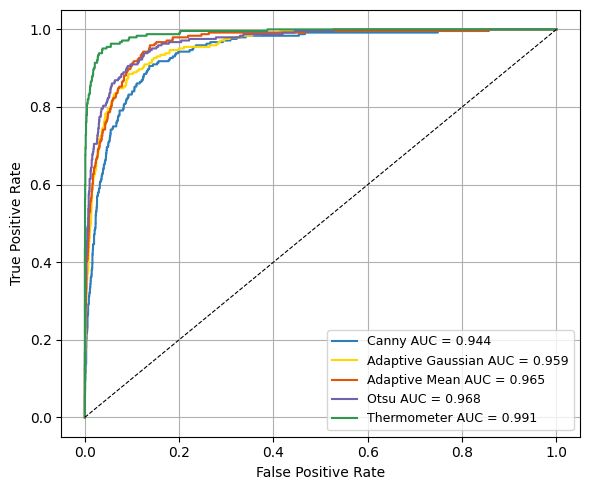


--- eosinophil ---
Saved to blood_roc_eosinophil.svg


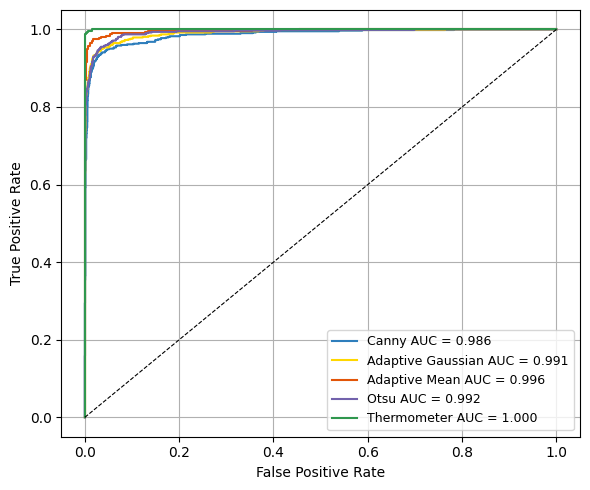


--- erythroblast ---
Saved to blood_roc_erythroblast.svg


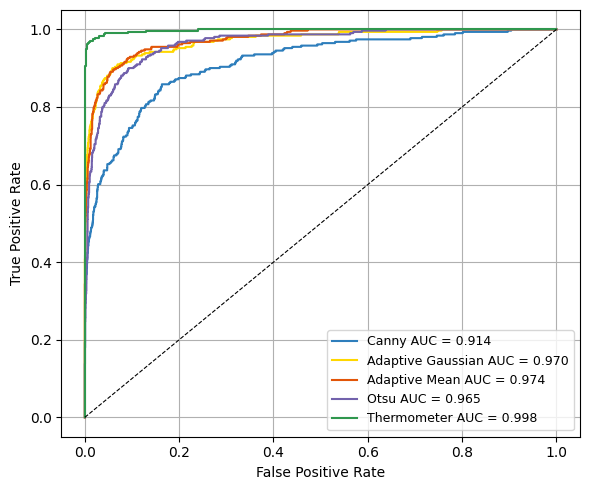


--- immature granulocyte ---
Saved to blood_roc_immature_granulocyte.svg


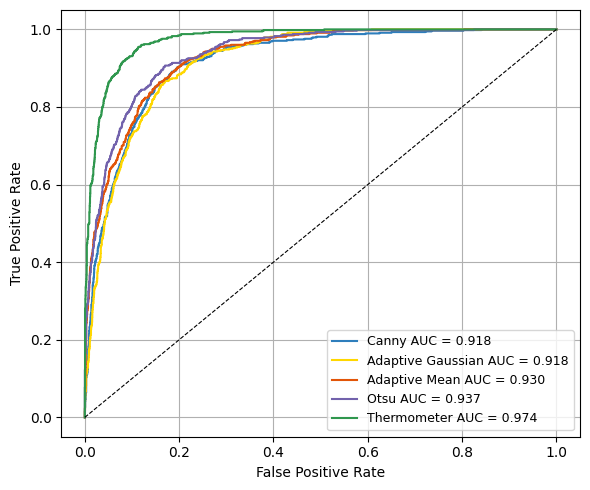


--- lymphocyte ---
Saved to blood_roc_lymphocyte.svg


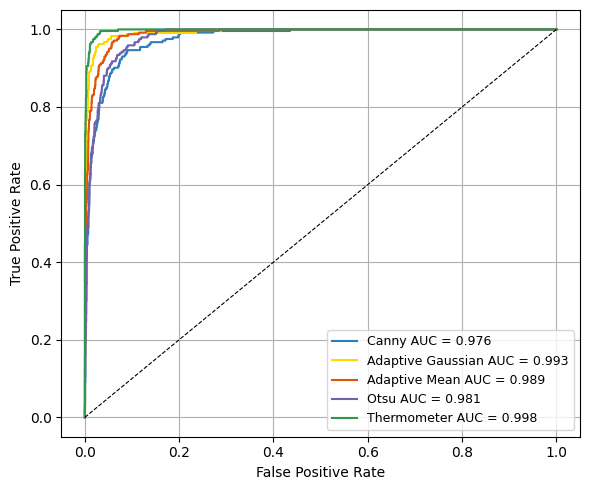


--- monocyte ---
Saved to blood_roc_monocyte.svg


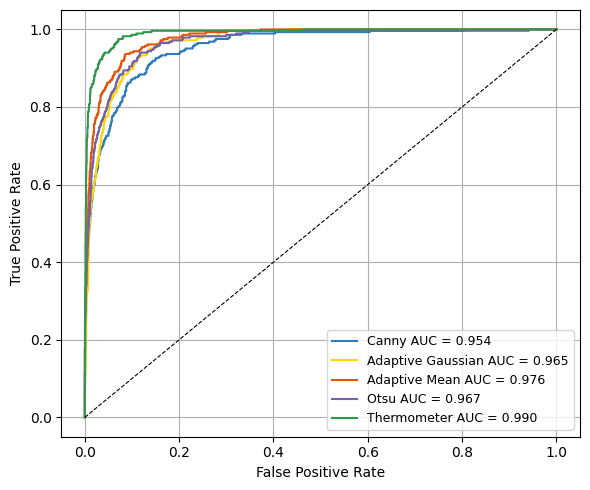


--- neutrophil ---
Saved to blood_roc_neutrophil.svg


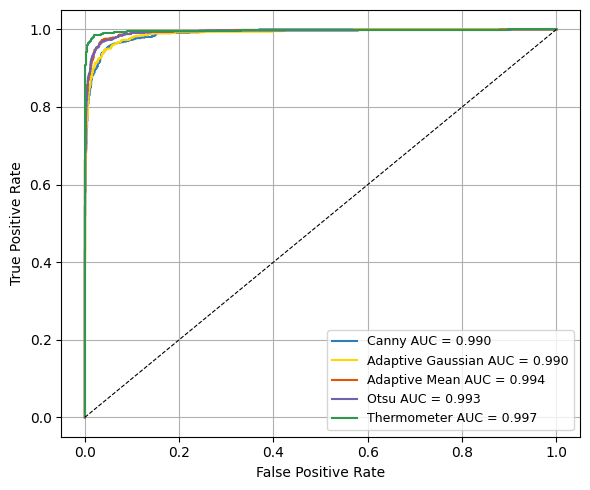


--- platelet ---
Saved to blood_roc_platelet.svg


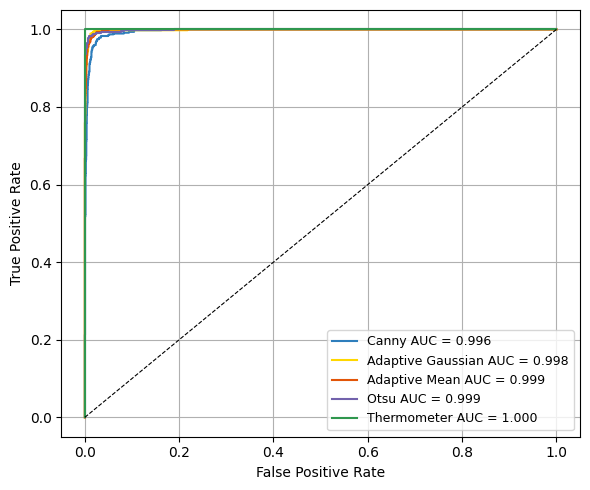

In [3]:

canny_path = os.path.join("saved_models", "BloodMNIST_Canny_Specialist.pkl")
with open(canny_path, "rb") as f:
    tm_canny = pickle.load(f)
    

tm_gaussian = os.path.join("saved_models", "BloodMNIST_Adaptive_Gaussian_Specialist.pkl")
with open(tm_gaussian, "rb") as f:
    tm_gaussian = pickle.load(f)

tn_mean = os.path.join("saved_models", "BloodMNIST_Adaptive_Mean_Specialist.pkl") 
with open(tn_mean, "rb") as f:
    tm_mean = pickle.load(f)

tm_otsu = os.path.join("saved_models", "BloodMNIST_Otsu_Specialist.pkl")
with open(tm_otsu, "rb") as f:
    tm_otsu = pickle.load(f)

tm_thermo = os.path.join("saved_models", "BloodMNIST_Color_Thermometers_Specialist.pkl")
with open(tm_thermo, "rb") as f:
    tm_thermo = pickle.load(f)
    
    
    
plot_tm_roc_curve_multi_specialist(
    config=config,
   params=[
        {"T_best": tm_canny.T, "s_best": tm_canny.s, "patch_best": tm_canny.patch_dim[0],
        "maxlit_best": tm_canny.max_included_literals, "weighted_best": 1},
        {"T_best": tm_gaussian.T, "s_best": tm_gaussian.s, "patch_best": tm_gaussian.patch_dim[0],
        "maxlit_best": tm_gaussian.max_included_literals, "weighted_best": 1},
        {"T_best": tm_mean.T, "s_best": tm_mean.s, "patch_best": tm_mean.patch_dim[0],
        "maxlit_best": tm_mean.max_included_literals, "weighted_best": 1},
        {"T_best": tm_otsu.T, "s_best": tm_otsu.s, "patch_best": tm_otsu.patch_dim[0],
        "maxlit_best": tm_otsu.max_included_literals, "weighted_best": 1},
        {"T_best": tm_thermo.T, "s_best": tm_thermo.s, "patch_best": tm_thermo.patch_dim[0],
        "maxlit_best": tm_thermo.max_included_literals, "weighted_best": 1},
    ],
        # ... repeat for each specialist

    filename_prefixes=[
        "BloodMNIST_Canny",
        "BloodMNIST_Adaptive_Gaussian",
        "BloodMNIST_Adaptive_Mean",
        "BloodMNIST_Otsu",
        "BloodMNIST_Color_Thermometers",
    ],
    specialist_names=["Canny", "Adaptive Gaussian", "Adaptive Mean", "Otsu", "Thermometer"],
    Y_test=Y_test,
    class_names=["basophil", "eosinophil", "erythroblast", "immature granulocyte", "lymphocyte", "monocyte", "neutrophil", "platelet"],
    save_path="blood_roc.svg"
)